In [1]:
import hcipy
from hcipy import *
import numpy as np
import matplotlib.pyplot as plt
# Set preferred matplotlib style
# Make cycle colorblind friendly 
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=plt.cm.tab10.colors)
def set_iraf_aas_style():
    """
    IRAF/AAS-inspired plotting style:
    serif fonts, inward ticks, clean axes, minimal grid.
    """
    plt.rcParams.update({
        # Fonts
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "dejavuserif",

        # Figure/export
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.format": "pdf",

        # Axes
        "axes.linewidth": 1.1,
        "axes.labelsize": 12,
        "axes.titlesize": 12,

        # Ticks
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.major.size": 5.5,
        "ytick.major.size": 5.5,
        "xtick.minor.size": 3.0,
        "ytick.minor.size": 3.0,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.minor.width": 0.8,
        "ytick.minor.width": 0.8,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,

        # Legend
        "legend.frameon": False,
        "legend.loc": "best",
        "legend.framealpha": 1.0,
        "legend.fontsize": 10,

        # Error bars
        "errorbar.capsize": 2.5,
        "lines.linewidth": 1.2,
    })

set_iraf_aas_style()

In [2]:
# These modules are used for animating some of the graphs in our notebook.
from matplotlib import animation, rc
from IPython.display import HTML

In [3]:
# SCExAO uses visible light for the PyWFS
wfs_wl = 500e-9 # 500 nm
D_tel = 8.2 # m
zero_mag_flux = 4e10 # photons/sec
stellar_mag = 0 # arbitrary 


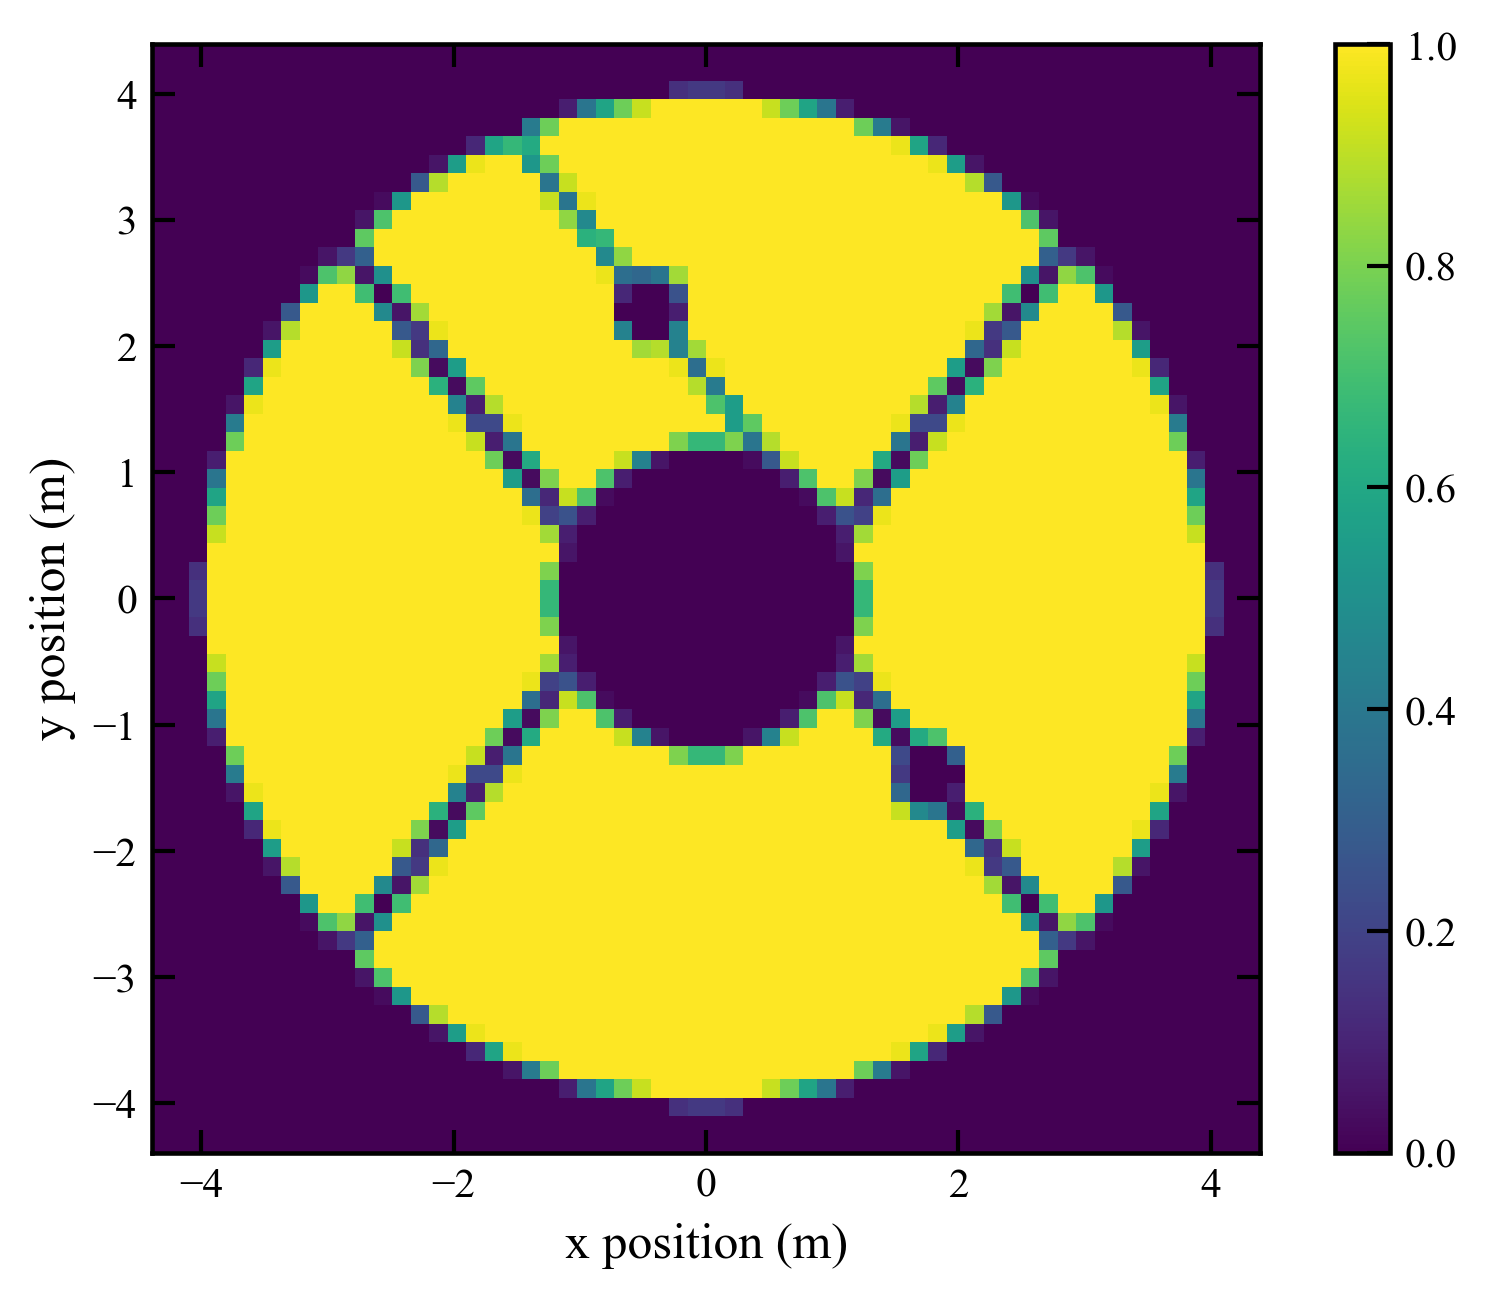

In [4]:
telescope_diameter = D_tel  # 8.2 m, defined earlier

num_pupil_pixels = 60
pupil_grid_diameter = 60 / 56 * telescope_diameter
pupil_grid = make_pupil_grid(num_pupil_pixels, pupil_grid_diameter)

pwfs_grid = make_pupil_grid(120, 2 * pupil_grid_diameter)

subaru_aperture = evaluate_supersampled(make_scexao_aperture(), pupil_grid, 6)

imshow_field(subaru_aperture)
plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.colorbar()
plt.show()

In [5]:
num_actuators_across_pupil = 45
actuator_spacing = telescope_diameter / num_actuators_across_pupil
influence_functions = make_gaussian_influence_functions(pupil_grid, num_actuators_across_pupil, actuator_spacing)
deformable_mirror = DeformableMirror(influence_functions)
num_modes = deformable_mirror.num_actuators

In [6]:
pwfs = PyramidWavefrontSensorOptics(pupil_grid, pwfs_grid, separation=pupil_grid_diameter, pupil_diameter=telescope_diameter, wavelength_0=wfs_wl, q=3)
camera = NoiselessDetector(pwfs_grid)

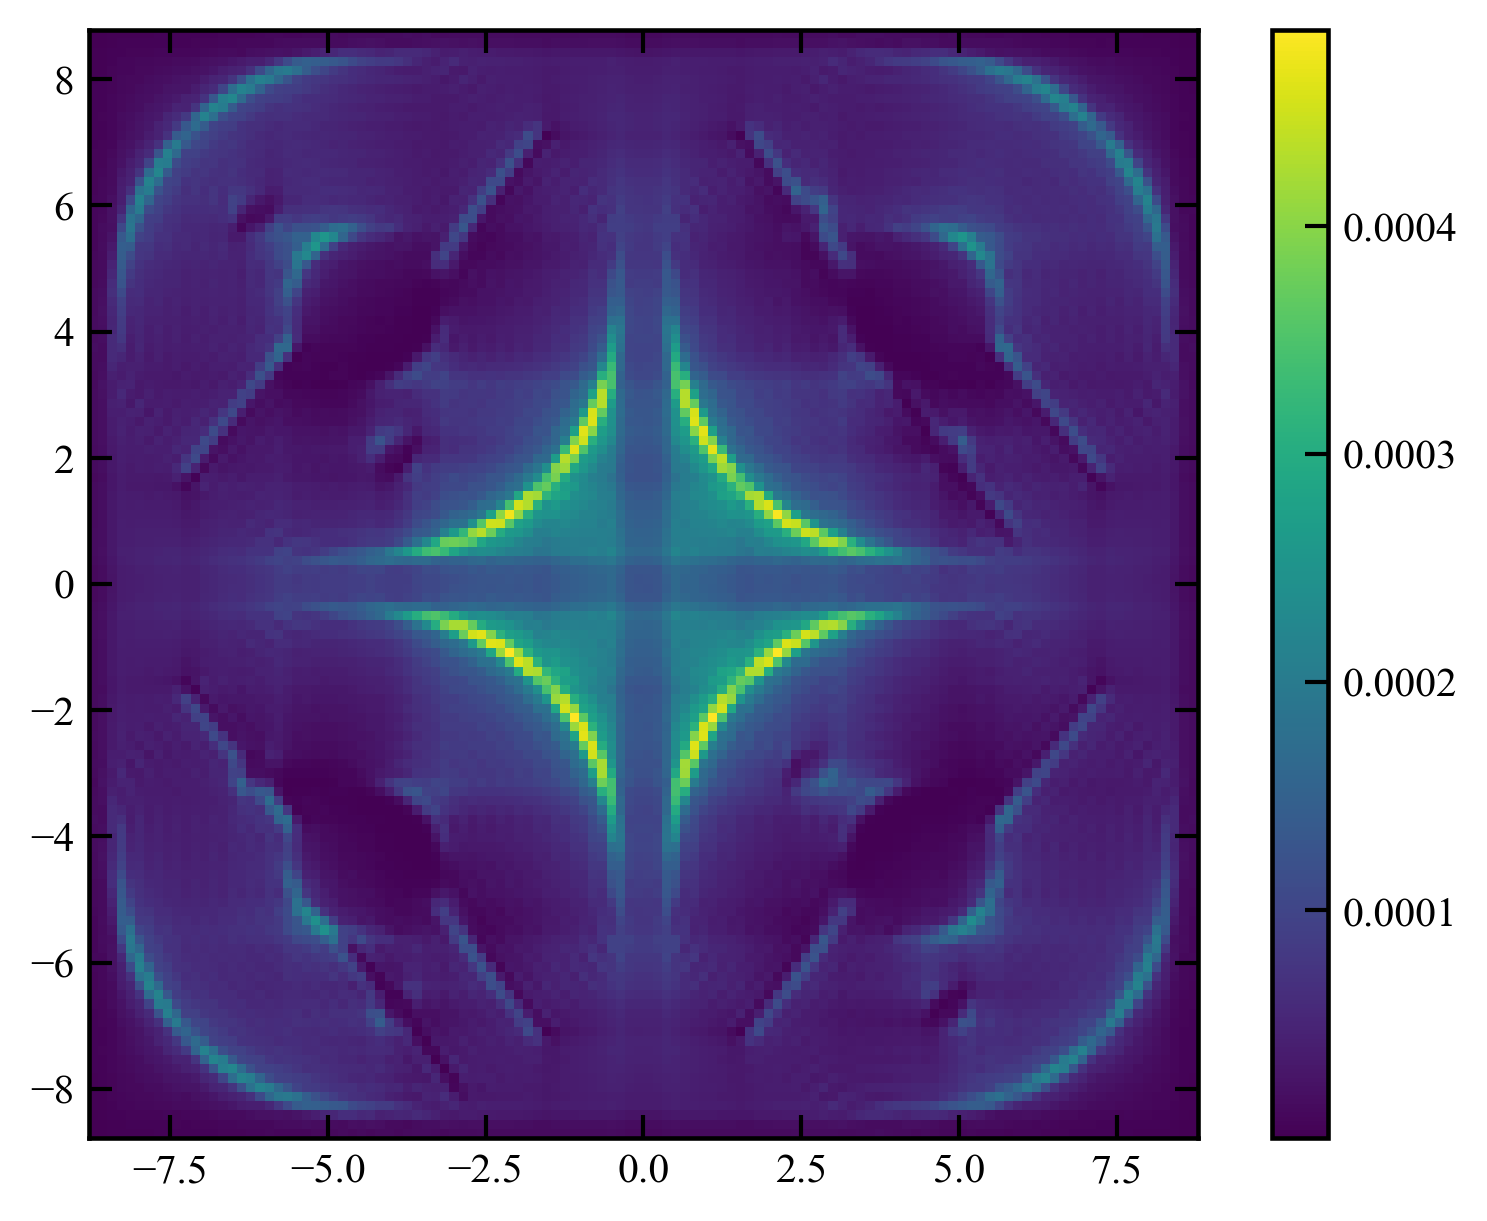

In [8]:
wf = Wavefront(subaru_aperture, wfs_wl)
wf.total_power = 10

camera.integrate(pwfs.forward(wf), 1)

image_ref = camera.read_out()
image_ref /= image_ref.sum()

imshow_field(image_ref)
plt.colorbar()
plt.show()

make the sure you understand equations
send some stuff to Nour 
Couple of slides during group meeting 
    - brief intro and what I'm going to be doing 
    